# *RNR1* Gene expression and chromatin deconvolution 

Now that we have settled on the VST transformation and fixed the CLOCCS parameters, the deconvolution for RNR1 seems stable. 

There is uncertainty with the combined model, but we can at least start looking at the chromatin deconvolutions in conjuction with the gene expression.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


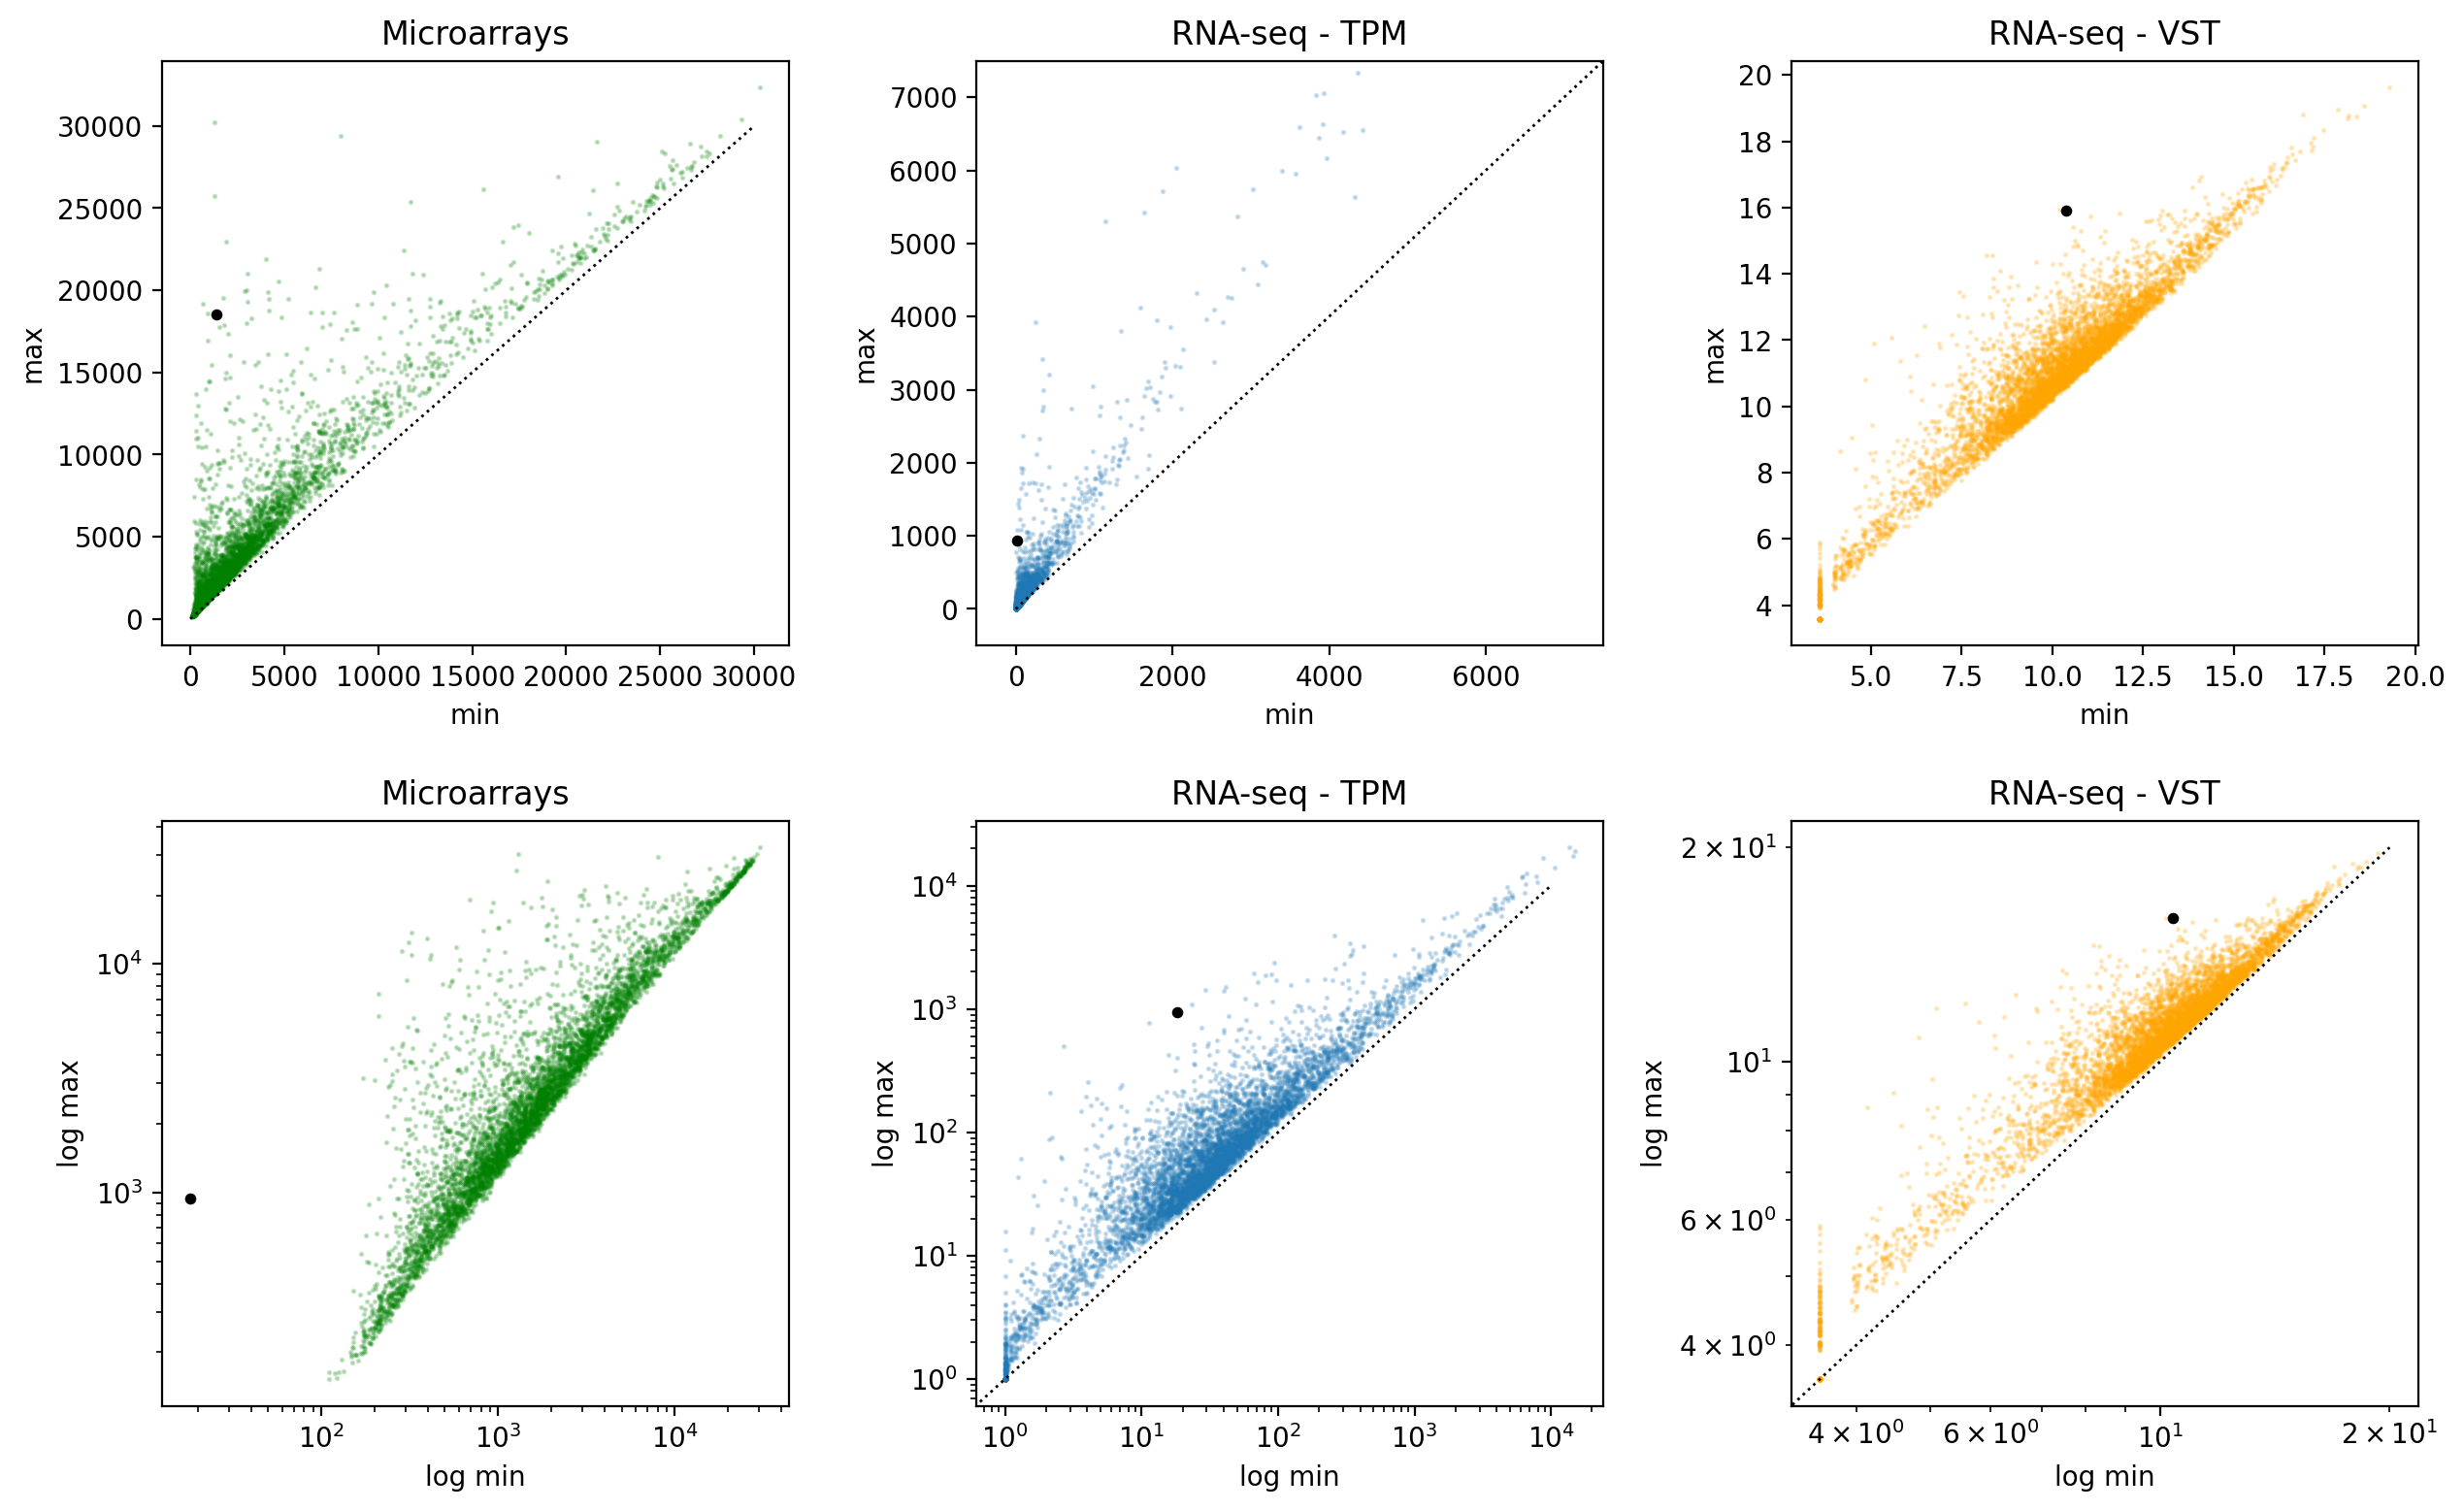

In [2]:
from src.normalization_analysis import NormAnalysis

norm_analysis = NormAnalysis()
norm_analysis.compute_meta()
norm_analysis.plot_differences()

In [3]:
tpm_values = norm_analysis.yl_rep1_TPM
vst_values = norm_analysis.yl_rep1_vst

mean_tpm = tpm_values.mean(axis=1)
mean_vst = vst_values.mean(axis=1)

Text(0.5, 1.0, 'RNA-seq Replicate 1, TPM vs VST normalization\nSpearman R=0.85, p-val=0.00')

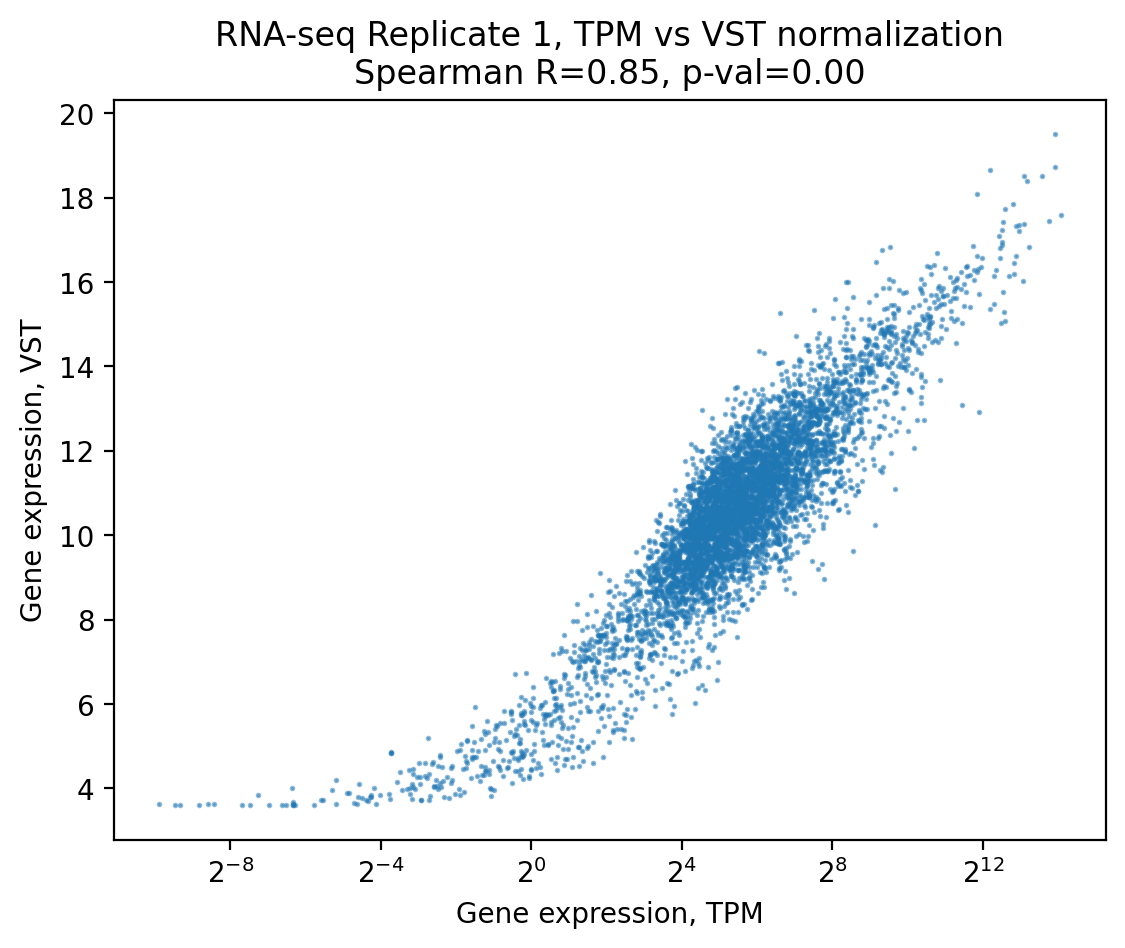

In [4]:
from scipy.stats import spearmanr

plt.scatter(mean_tpm, mean_vst, s=1, alpha=0.5)
plt.xscale('log', base=2)

spearmanrval, spearmanp = spearmanr(mean_tpm, mean_vst)
plt.ylabel("Gene expression, VST")
plt.xlabel("Gene expression, TPM")

plt.title(f"RNA-seq Replicate 1, TPM vs VST normalization\n"
          f"Spearman R={spearmanrval:.2f}, p-val={spearmanp:.2f}")

Text(0.5, 1.0, 'Original VST PTR vs Original TPM PTR\nSpearman R=0.77, p-val=0.00')

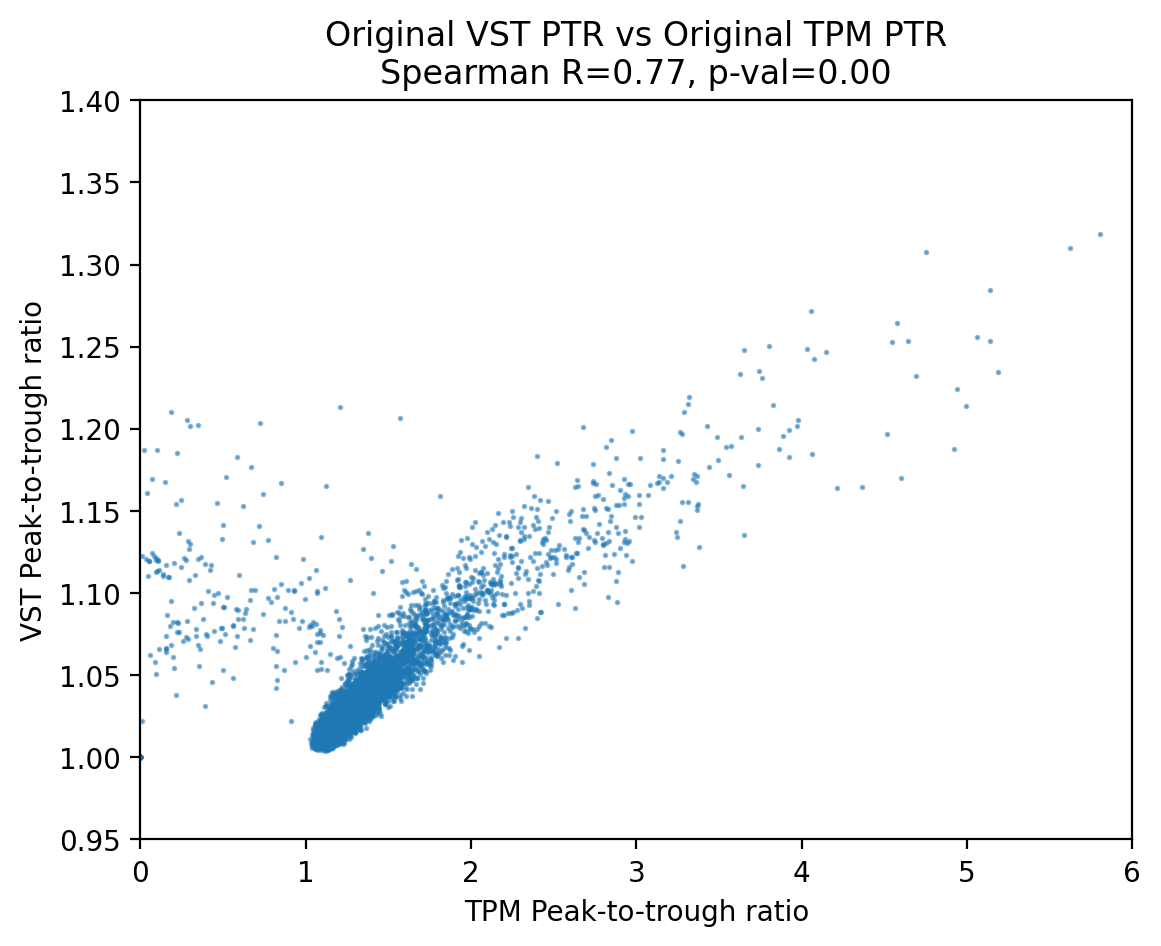

In [5]:
# Let's next check the peak to trough ratio

from cc_src.peak_to_trough import compute_80_20_ptr
vst_ptrs = vst_values.apply(compute_80_20_ptr, axis=1)
tpm_ptrs = tpm_values.apply(compute_80_20_ptr, axis=1)

plt.scatter(tpm_ptrs, vst_ptrs, alpha=0.5, s=1)
plt.xlim(0, 6)
plt.ylim(0.95, 1.4)
plt.xlabel("TPM Peak-to-trough ratio")
plt.ylabel("VST Peak-to-trough ratio")

spearmanrval, spearmanpval = spearmanr(tpm_ptrs, vst_ptrs)
plt.title(f"Original VST PTR vs Original TPM PTR\n"
          f"Spearman R={spearmanrval:.2f}, p-val={spearmanpval:.2f}")


0

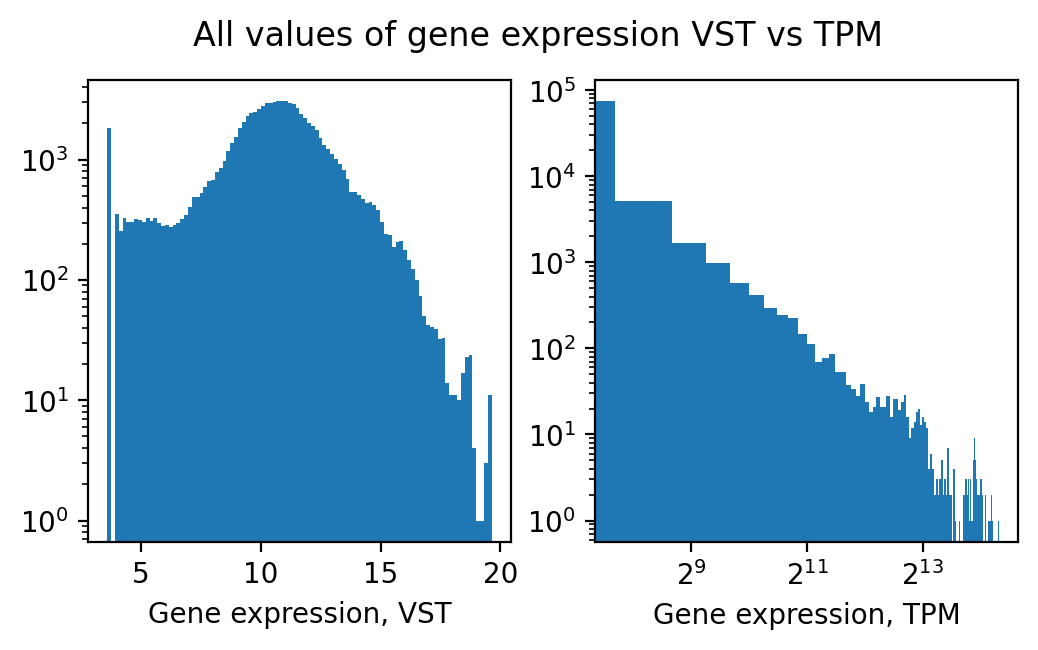

In [6]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.hist(vst_values.values.flatten(), bins=100)
plt.yscale('log', base=10)
plt.xlabel("Gene expression, VST")

plt.subplot(1, 2, 2)
plt.hist(tpm_values.values.flatten(), bins=100)
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.xlabel("Gene expression, TPM")

plt.suptitle("All values of gene expression VST vs TPM")
0


In [17]:
from src.config import load_combined_yl_vst_gene_expression_config
from src.model import Model

def plot_and_save_model_config(gene_name, config, model_name):
    model = Model(config, gene_name, 0.0001)
    model.deconvolve()
    model.plot_deconvolved_gene()
    plt.savefig(f'{save_dir}/{gene_name}_{model_name}.png', dpi=150)
    return model

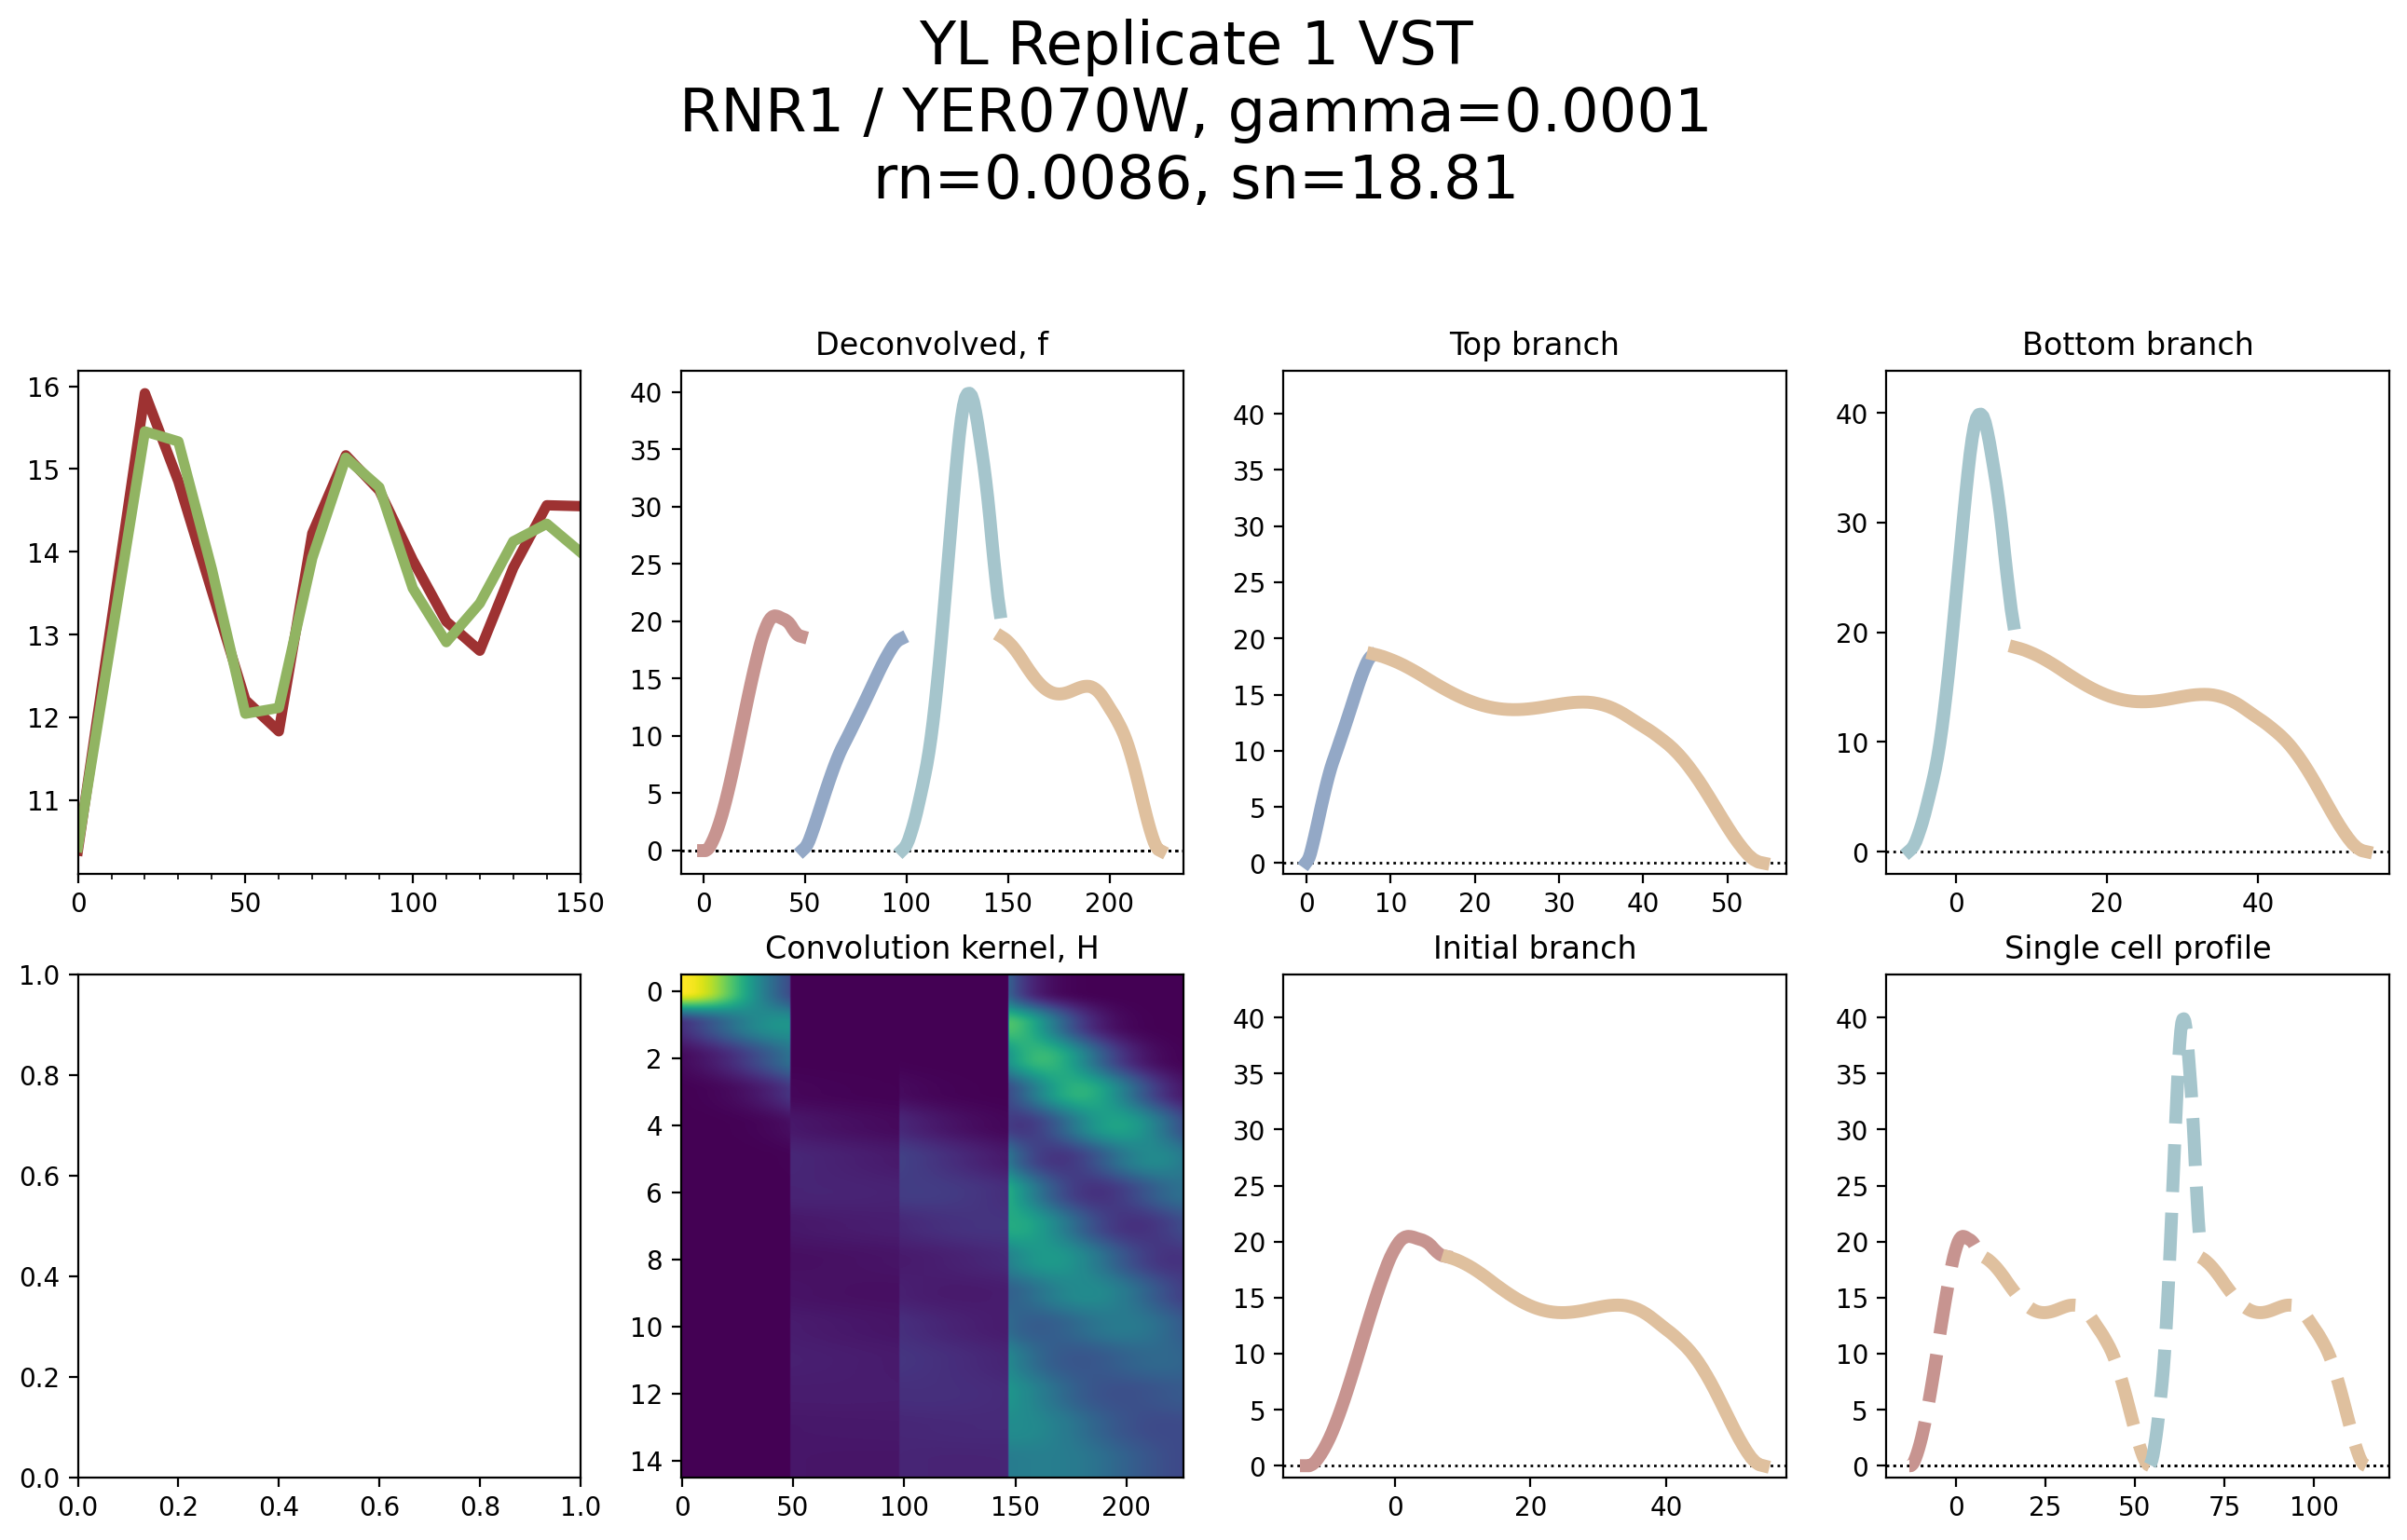

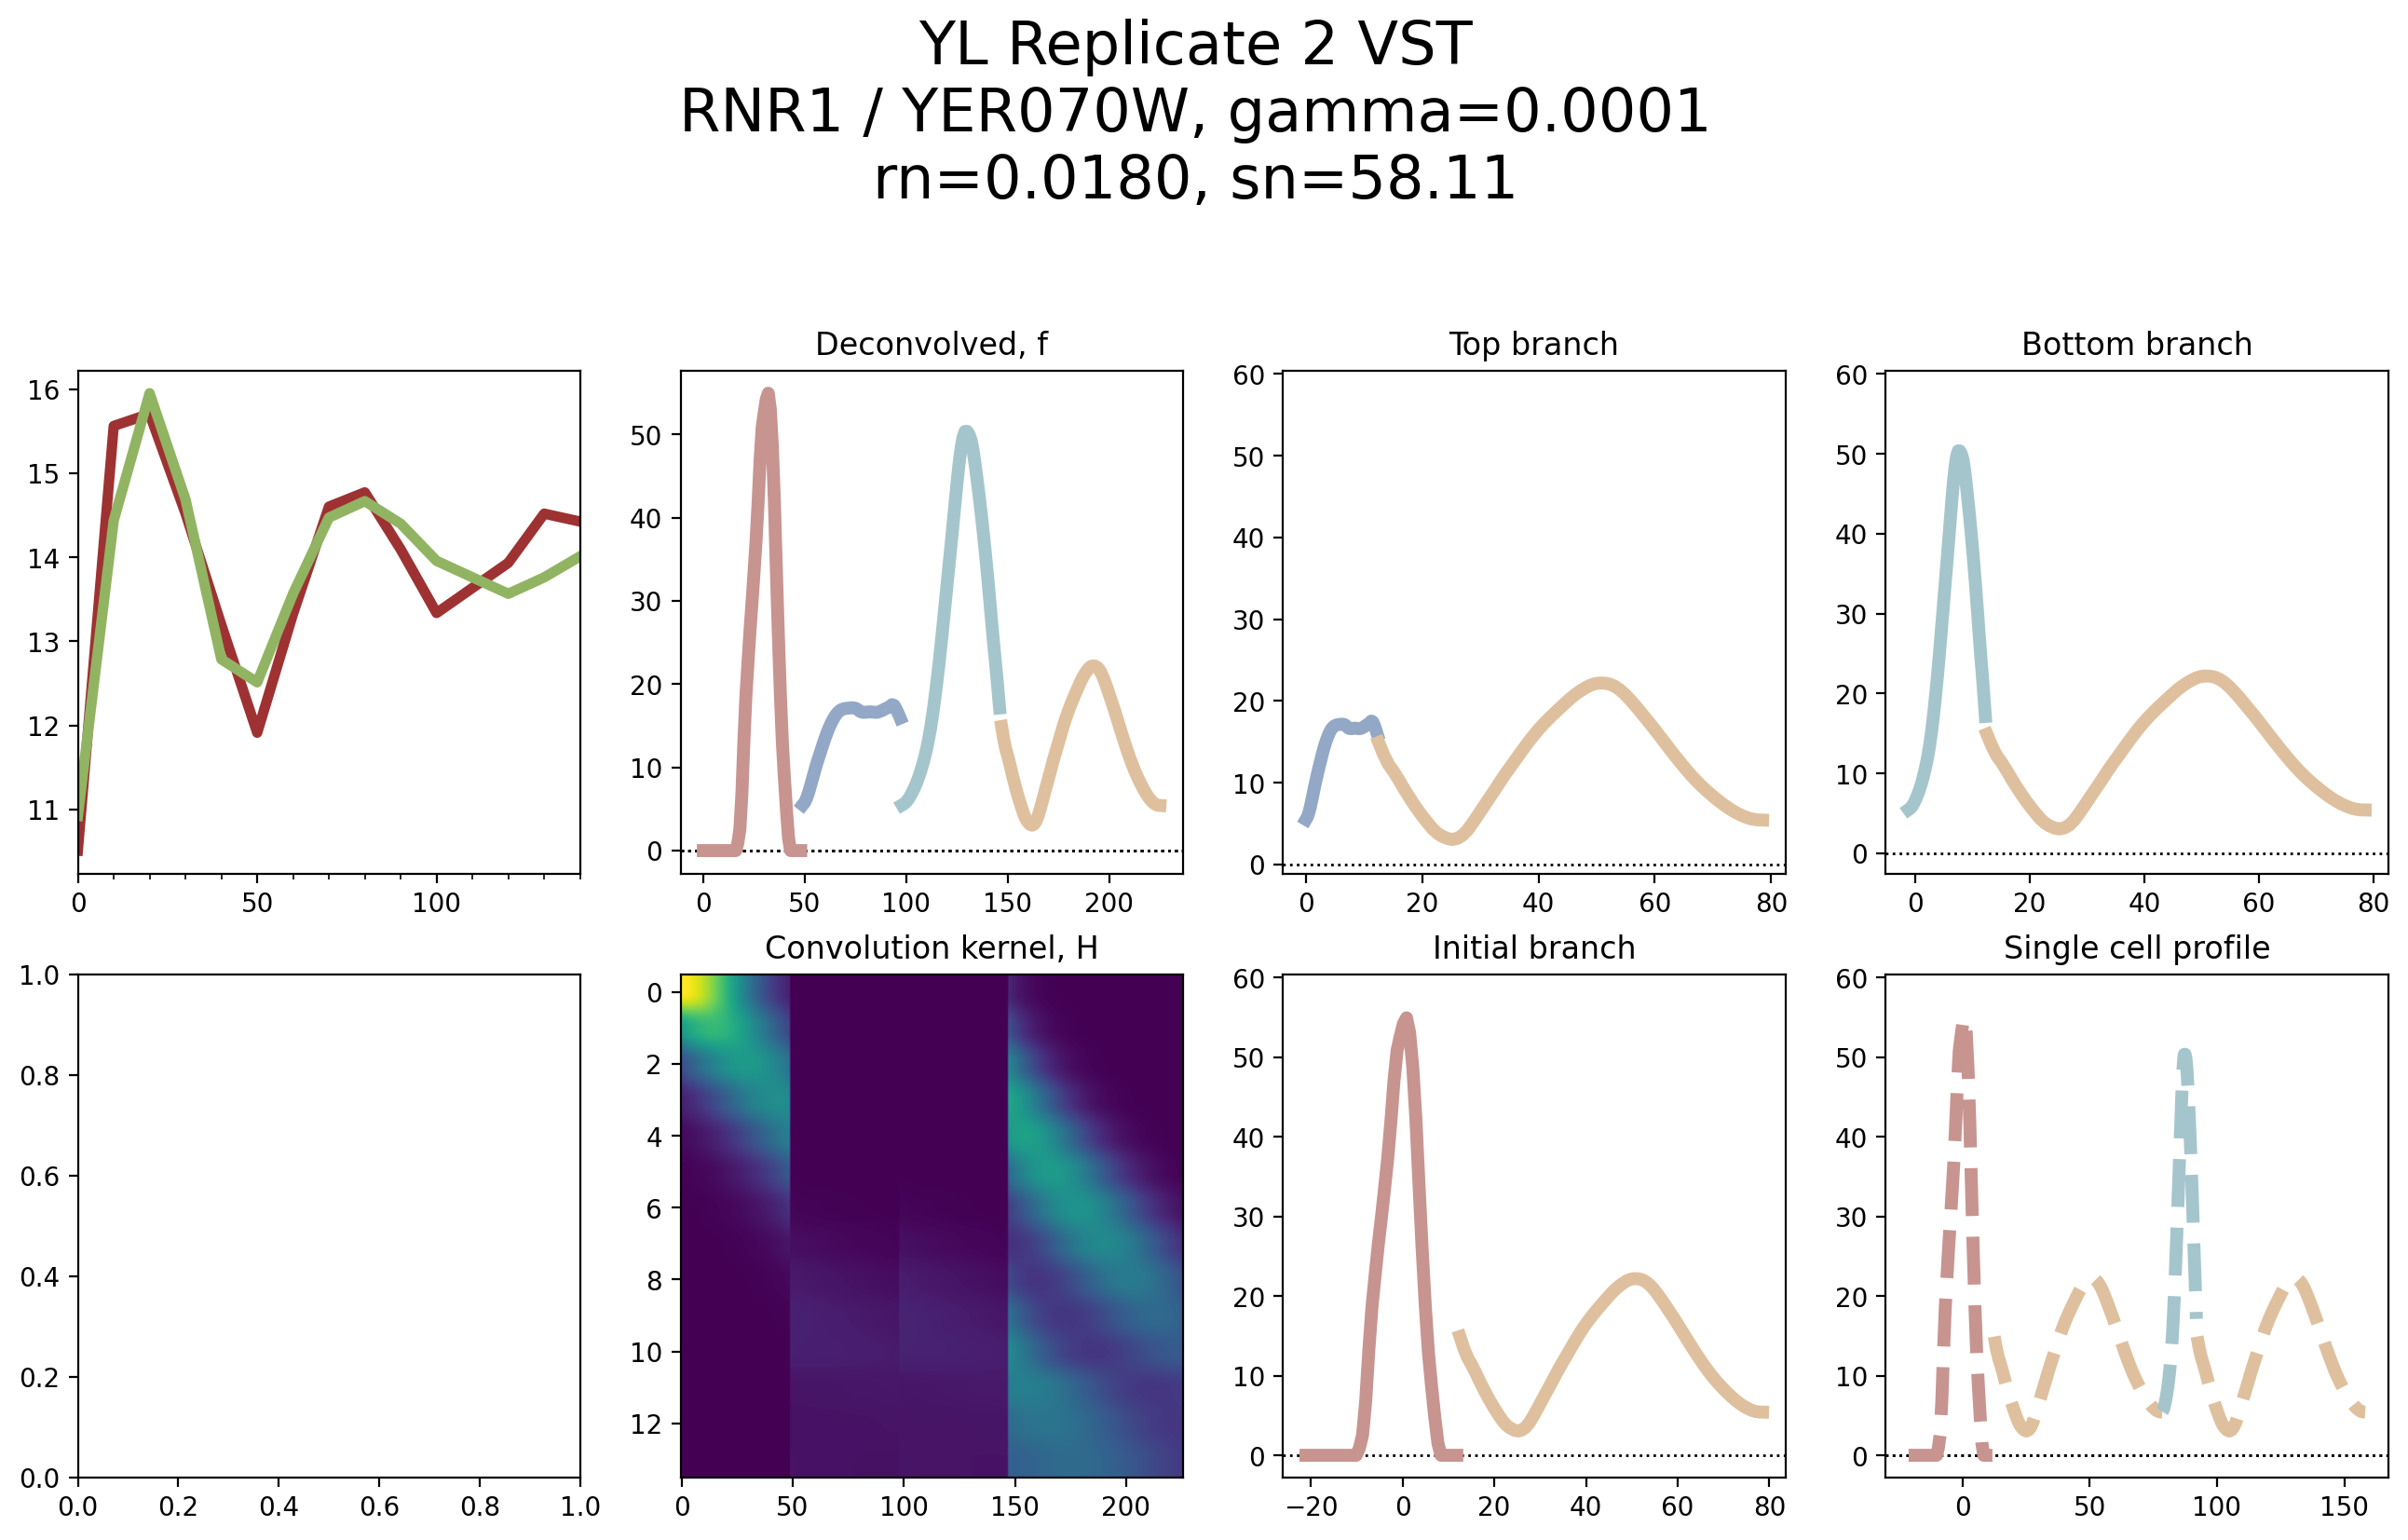

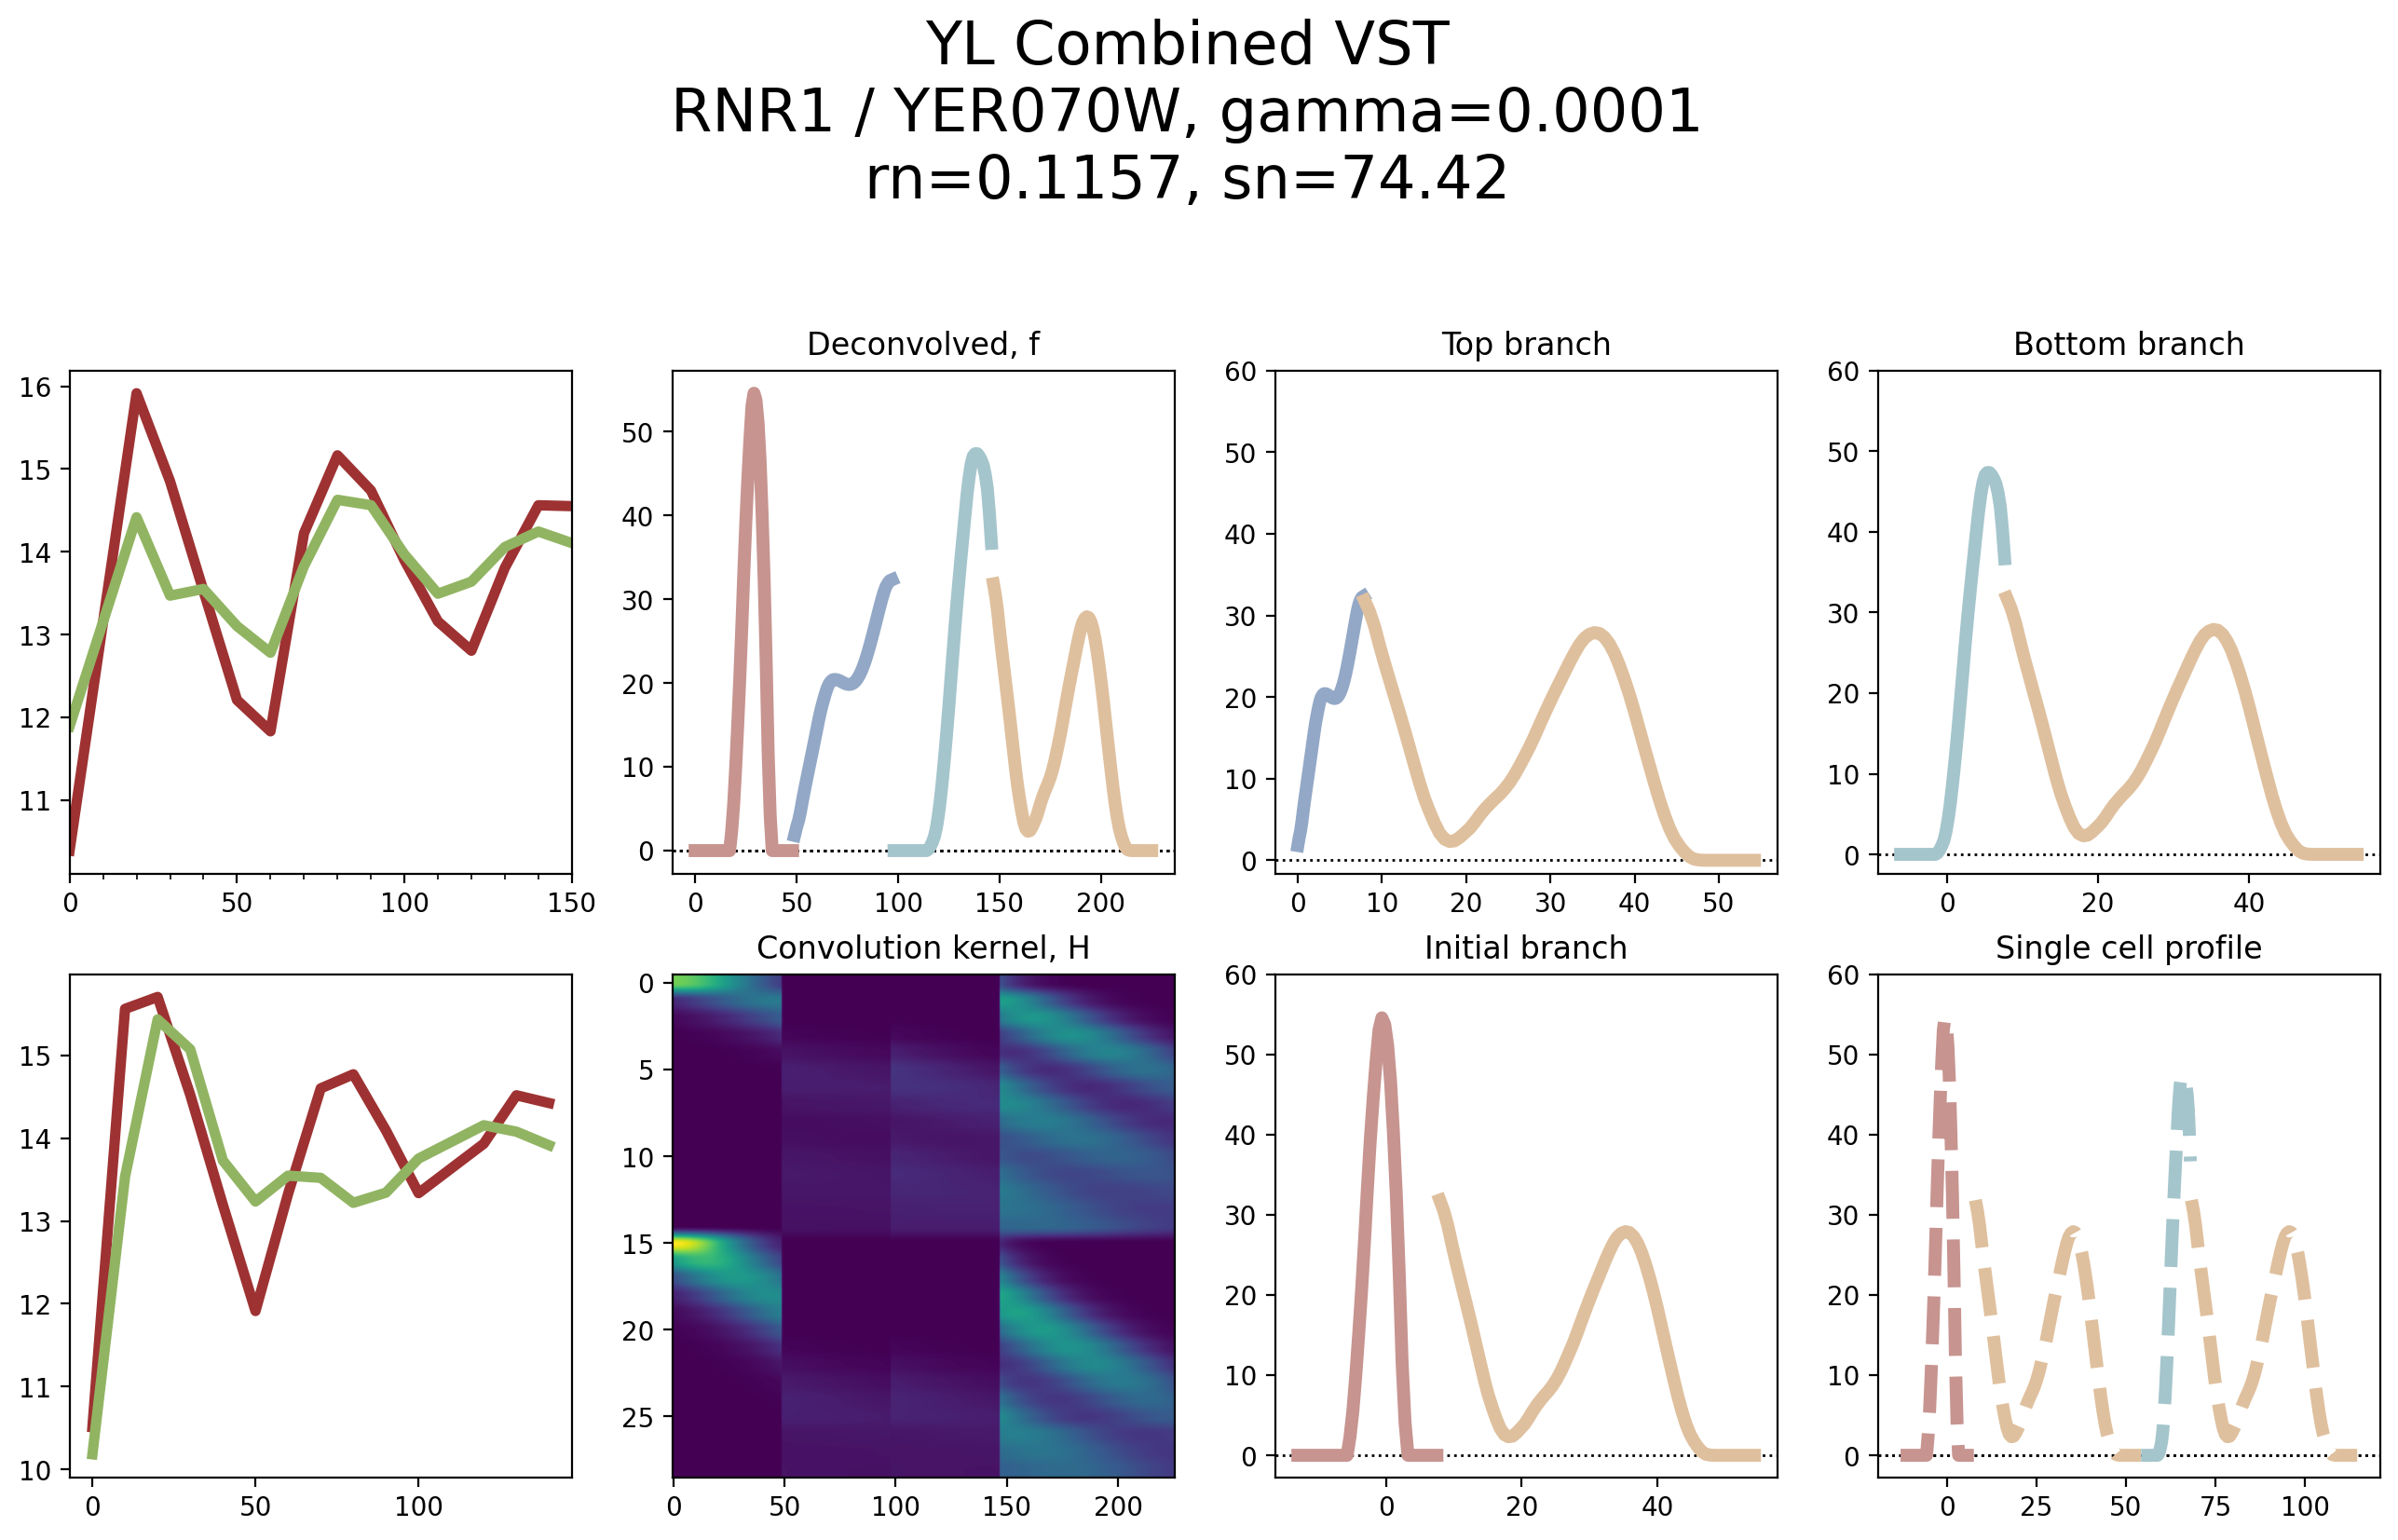

In [63]:
from src.config import load_yl_replicate1_rg1_vst_config, load_yl_replicate2_rg1_vst_config

save_dir = 'output/positive_controls/comparison_rep1_vs_rep2_vs_combined'

config1 = load_yl_replicate1_rg1_vst_config()
config_combined = load_combined_yl_vst_gene_expression_config()
config2 = load_yl_replicate2_rg1_vst_config()

ge_model1 = plot_and_save_model_config('RNR1', config1, 'Replicate 1')
ge_model2 = plot_and_save_model_config('RNR1', config2, 'Replicate 2')
ge_model_combined = plot_and_save_model_config('RNR1', config_combined, 'Combined')


In [77]:
from src.config import load_yl_replicate2_rg1_chromatin_config, \
    load_yl_replicate1_rg1_chromatin_config
from cc_src.chromatin_grid_compute import ChromatinGrid
from src.deconvolution_plotter import DeconvolutionPlotter
from src.deconvolve_chromatin import deconvolve_chromatin

def deconvolve_chrom_gene(chrom1_config, genename, gamma, replicate):
    chrom1_model = Model(chrom1_config, genename, gamma)

    chromatin_gridder = ChromatinGrid()
    chromatin_gridder.set_gene(chrom1_model.orf_name, replicate=replicate)
    chromatin_gridder.create_bins_per_all_sample()
    chromatin_gridder.create_deconvolution_matrices()
    f = deconvolve_chromatin(chrom1_model, chromatin_gridder.deconv_hist)
    return chrom1_model, chromatin_gridder


Loading MNase reads...Done.
The histogram shape around the TSS is: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


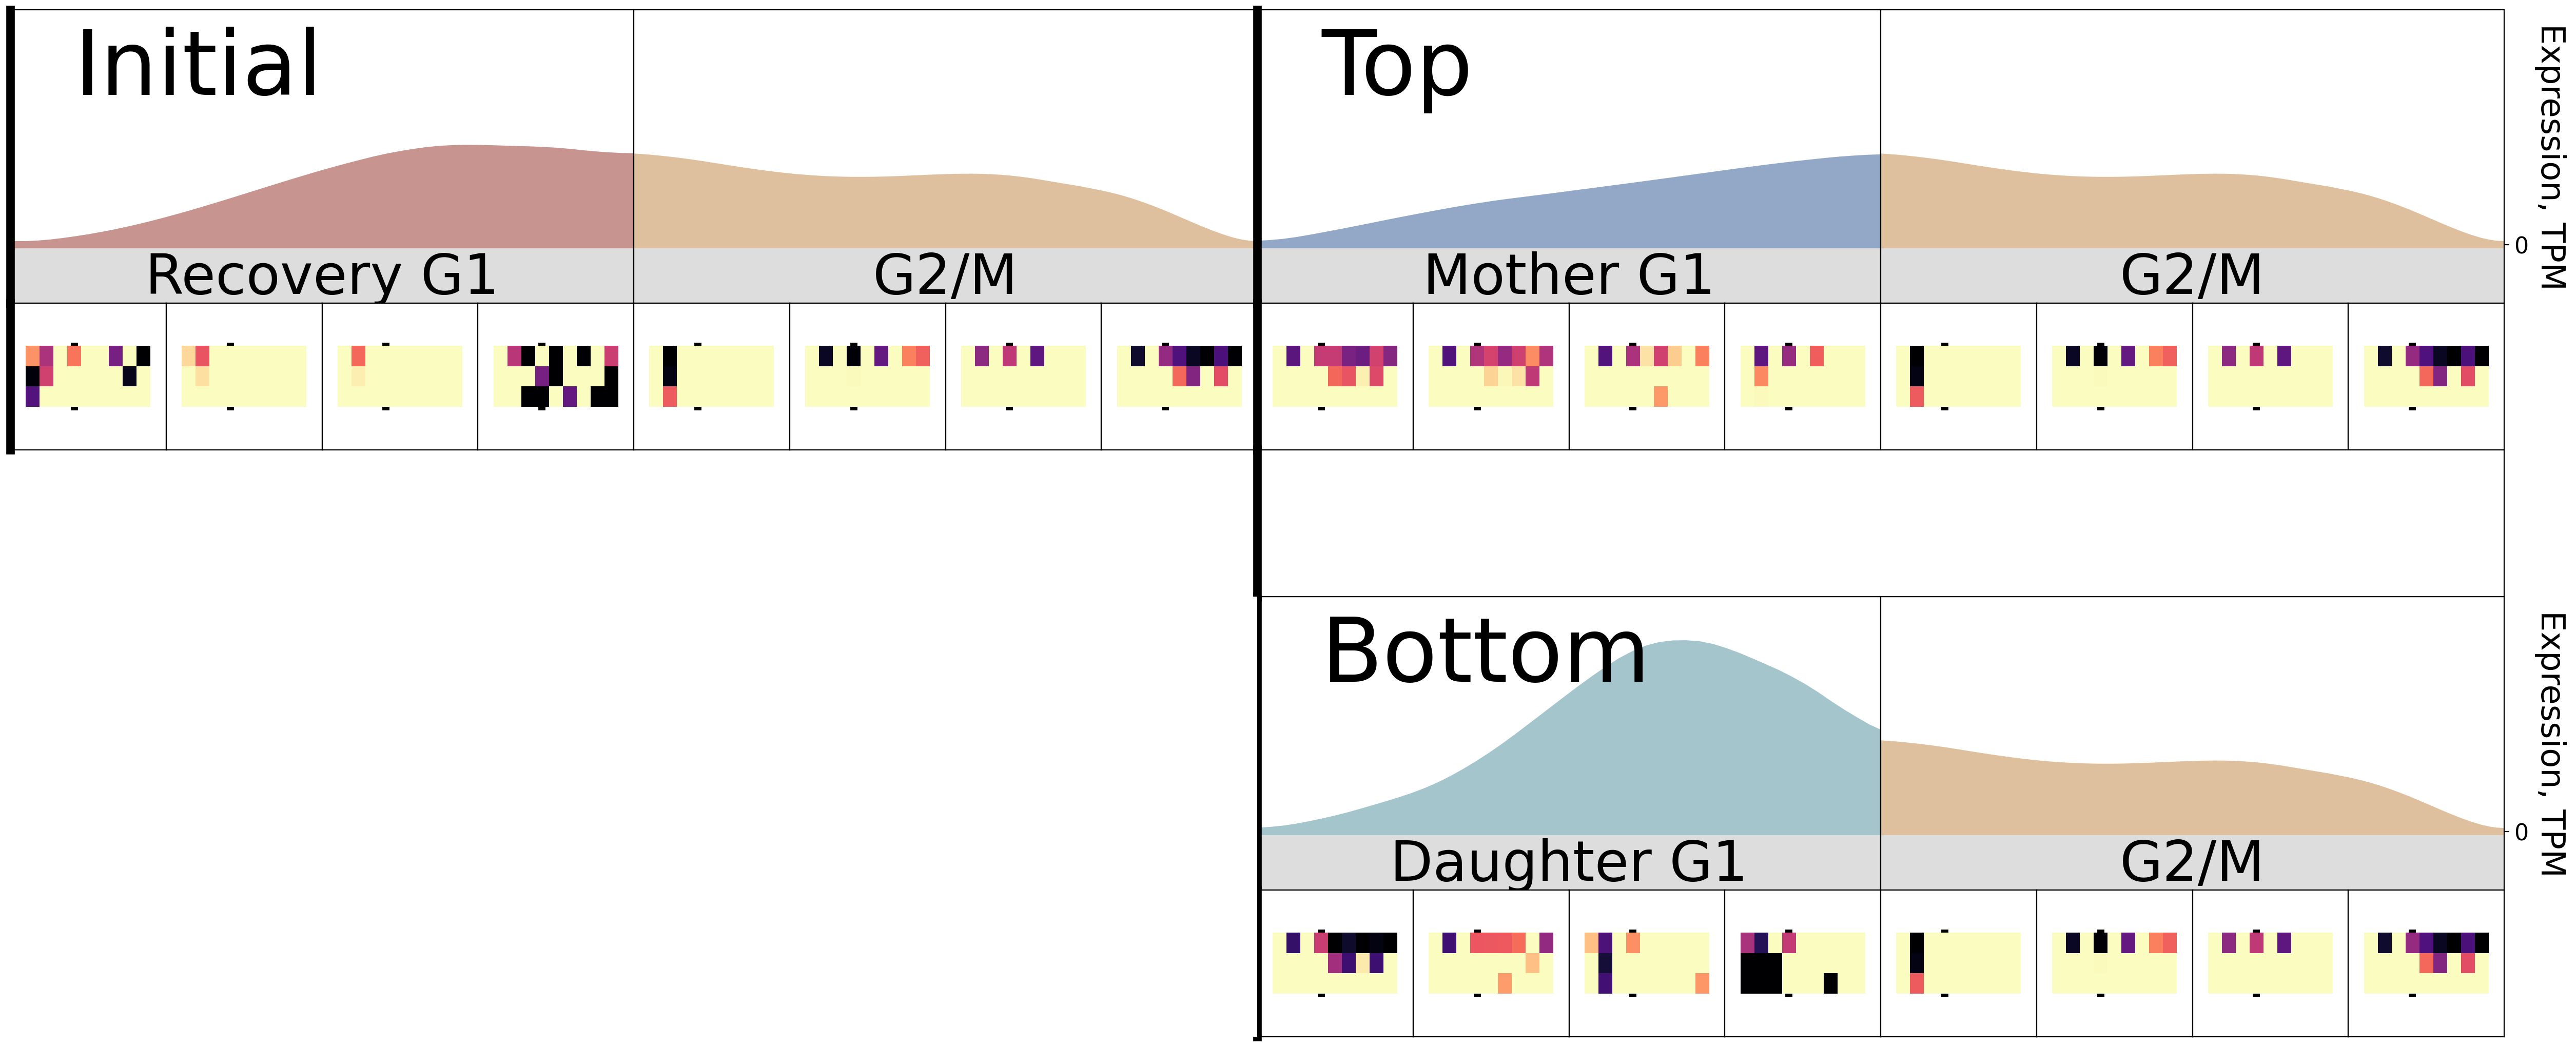

In [78]:
# Deconvolve the chromatin of replicate 1
chrom1_config = load_yl_replicate1_rg1_chromatin_config()
chrom1_model, chrom1_gridder = deconvolve_chrom_gene(chrom1_config, 'RNR1',
    0.0001, replicate=1)

plotter = DeconvolutionPlotter(ge_model1, chrom1_gridder, chrom1_model)
plotter.plot_deconvolved_models()


Loading MNase reads...Done.
The histogram shape around the TSS is: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


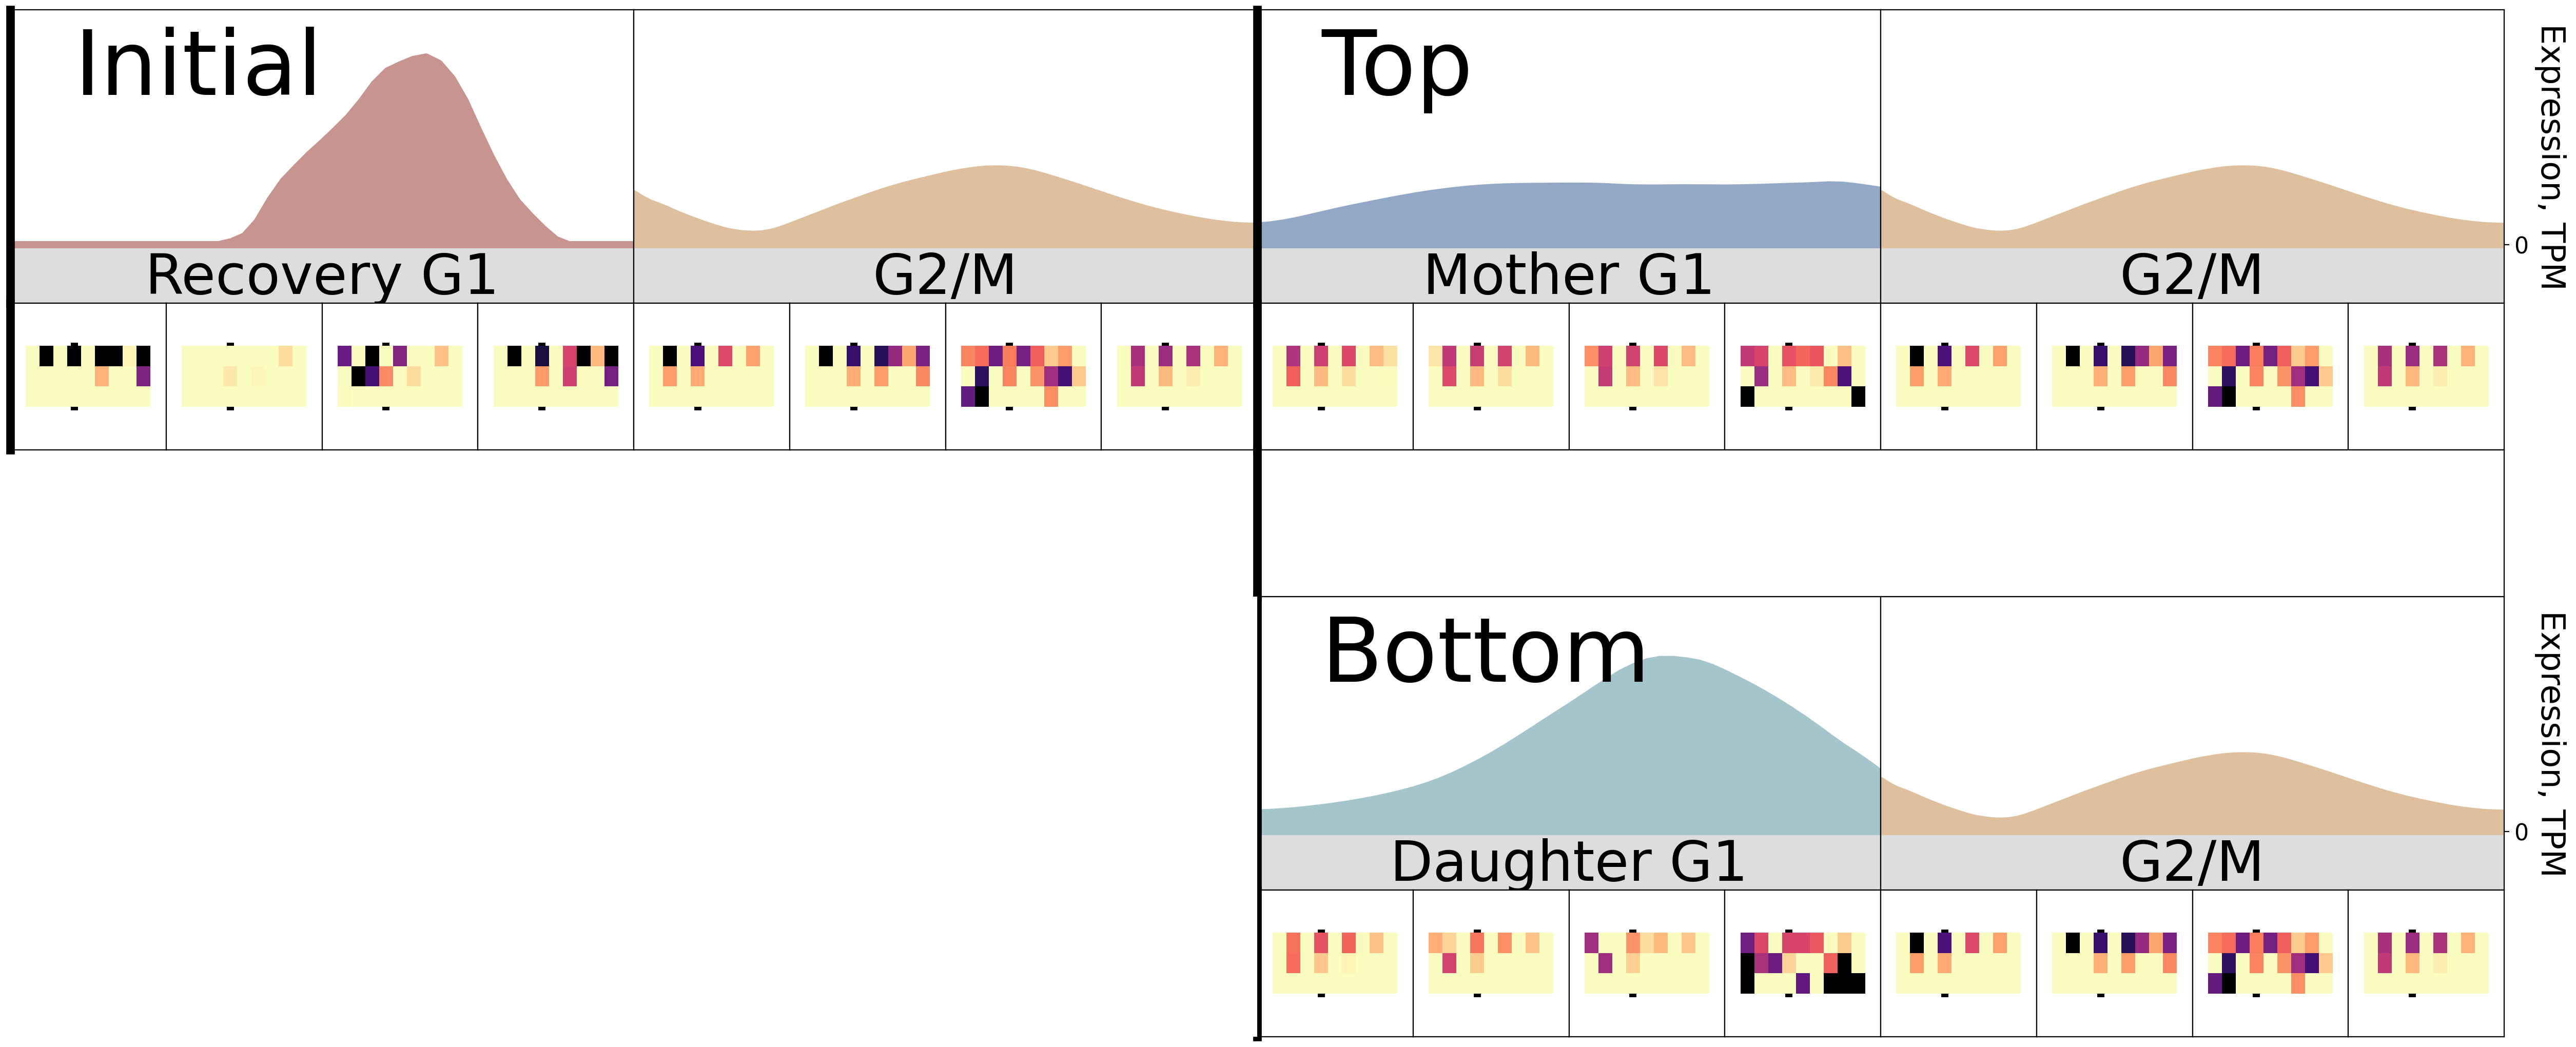

In [79]:
# Deconvolve the chromatin of replicate 2
chrom2_config = load_yl_replicate2_rg1_chromatin_config()
chrom2_model, chrom2_gridder = deconvolve_chrom_gene(chrom2_config, 'RNR1', 
    0.0001, replicate=2)

plotter = DeconvolutionPlotter(ge_model2, chrom2_gridder, chrom2_model)
plotter.plot_deconvolved_models()
